# Geocode Stations

**Run this notebook once.** It geocodes the 873 station addresses using Nominatim (free, no API key required) and saves the results to `data/interim/station_coordinates.csv`.

**Input:** `data/raw/PlusDR_Location_Info.xlsx`  
**Output:** `data/interim/station_coordinates.csv`

> Rate limit: Nominatim allows 1 request/second. 873 stations ≈ 15 minutes.

## 0. Setup

In [1]:
import pandas as pd
import time
from pathlib import Path
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderServiceError

# Find project root
current = Path.cwd().resolve()
PROJECT_ROOT = None
for candidate in [current, *current.parents]:
    if (candidate / 'data' / 'raw').exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError('Could not find the project root containing data/raw')

LOCATION_PATH = PROJECT_ROOT / 'data' / 'raw' / 'PlusDR_Location_Info.xlsx'
OUT_PATH      = PROJECT_ROOT / 'data' / 'interim' / 'station_coordinates.csv'

print(f'Input:  {LOCATION_PATH}')
print(f'Output: {OUT_PATH}')

Input:  /Users/alemz/Desktop/Uni/Coding/Github/AI2_Project/data/raw/PlusDR_Location_Info.xlsx
Output: /Users/alemz/Desktop/Uni/Coding/Github/AI2_Project/data/interim/station_coordinates.csv


## 1. Load Station Addresses

In [2]:
raw = pd.read_excel(LOCATION_PATH).rename(columns={
    'Customer ID': 'customer_id',
    'Address':     'address',
    'City':        'city',
    'Province':    'province',
})

stations = raw[['customer_id', 'address', 'city', 'province']].copy()
stations['customer_id'] = pd.to_numeric(stations['customer_id'], errors='coerce').astype('int64')

print(f'Stations to geocode: {len(stations)}')
stations.head(5)

Stations to geocode: 873


,customer_id,address,city,province
0,813422319,"Odeung-dong, Ara-dong, Jeju, 63238, South Korea",Jeju-si,Jeju Island
1,813234683,"Hagwi 2(i)-ri, Aewol, Jeju, 63051, South Korea",Jeju-si,Jeju Island
2,813127497,"Jocheon-ri, Jocheon, Jeju, South Korea",Jeju-si,Jeju Island
3,813127488,"Jocheon-ri, Jocheon, Jeju, South Korea",Jeju-si,Jeju Island
4,813229421,"Jocheon-ri, Jocheon, Jeju, South Korea",Jeju-si,Jeju Island


## 2. Resume Check

If the output file already exists (e.g. from a previous interrupted run), skip stations already geocoded.

In [3]:
if OUT_PATH.exists():
    existing = pd.read_csv(OUT_PATH)
    already_done = set(existing['customer_id'])
    print(f'Resuming — {len(already_done)} stations already geocoded, {len(stations) - len(already_done)} remaining')
else:
    existing = pd.DataFrame(columns=['customer_id', 'address', 'city', 'province', 'lat', 'lon', 'geocode_status'])
    already_done = set()
    print('Starting fresh — no existing output found')

to_geocode = stations[~stations['customer_id'].isin(already_done)].reset_index(drop=True)
print(f'Stations to process: {len(to_geocode)}')

Starting fresh — no existing output found
Stations to process: 873


## 3. Geocode

In [4]:
geolocator = Nominatim(user_agent='ev_jeju_project', timeout=10)

results = []
failed  = []

for idx, row in to_geocode.iterrows():
    address = row['address']
    status  = 'ok'
    lat, lon = None, None

    try:
        location = geolocator.geocode(address)
        if location:
            lat = location.latitude
            lon = location.longitude
        else:
            # Fallback: try with just city + province
            fallback = f"{row['city']}, {row['province']}, South Korea"
            location = geolocator.geocode(fallback)
            if location:
                lat = location.latitude
                lon = location.longitude
                status = 'fallback_city'
            else:
                status = 'failed'
                failed.append(row['customer_id'])

    except (GeocoderTimedOut, GeocoderServiceError) as e:
        status = f'error: {e}'
        failed.append(row['customer_id'])

    results.append({
        'customer_id':    row['customer_id'],
        'address':        address,
        'city':           row['city'],
        'province':       row['province'],
        'lat':            lat,
        'lon':            lon,
        'geocode_status': status,
    })

    # Progress every 50 stations
    if (idx + 1) % 50 == 0 or (idx + 1) == len(to_geocode):
        print(f'  {idx + 1:>4} / {len(to_geocode)}  — failed so far: {len(failed)}')

    time.sleep(1)  # Nominatim rate limit

print(f'\nDone. Failed: {len(failed)}')
if failed:
    print(f'Failed IDs: {failed}')

    50 / 873  — failed so far: 0
   100 / 873  — failed so far: 0
   150 / 873  — failed so far: 0
   200 / 873  — failed so far: 0
   250 / 873  — failed so far: 0
   300 / 873  — failed so far: 0
   350 / 873  — failed so far: 0
   400 / 873  — failed so far: 0
   450 / 873  — failed so far: 0
   500 / 873  — failed so far: 0
   550 / 873  — failed so far: 0
   600 / 873  — failed so far: 0
   650 / 873  — failed so far: 0
   700 / 873  — failed so far: 0
   750 / 873  — failed so far: 0
   800 / 873  — failed so far: 0
   850 / 873  — failed so far: 0
   873 / 873  — failed so far: 0

Done. Failed: 0


## 4. Save

In [5]:
new_results = pd.DataFrame(results)
combined = pd.concat([existing, new_results], ignore_index=True)
combined.to_csv(OUT_PATH, index=False)

print(f'Saved {len(combined)} stations → {OUT_PATH}')
print(f"\nGeocoding status breakdown:")
print(combined['geocode_status'].value_counts())

ok_count = combined['lat'].notna().sum()
print(f'\nStations with coordinates: {ok_count} / {len(combined)}')

Saved 873 stations → /Users/alemz/Desktop/Uni/Coding/Github/AI2_Project/data/interim/station_coordinates.csv

Geocoding status breakdown:
geocode_status
ok    873
Name: count, dtype: int64

Stations with coordinates: 873 / 873


/var/folders/mc/flvh8wc14rv9v10rm091b74m0000gn/T/ipykernel_24964/3642625210.py:2: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = pd.concat([existing, new_results], ignore_index=True)


## 5. Quick Sanity Check

All stations should land on Jeju Island (lat ≈ 33.3–33.6, lon ≈ 126.1–126.9).

Stations outside Jeju bounding box: 8
     customer_id                                       address        lat  \
136    813688666  Yeonpyeong-ri, Udo, Jeju, 63365, South Korea  33.506329   
149    811152104  Yeonpyeong-ri, Udo, Jeju, 63365, South Korea  33.506329   
150    813987511  Yeonpyeong-ri, Udo, Jeju, 63365, South Korea  33.506329   
151    813987478  Yeonpyeong-ri, Udo, Jeju, 63365, South Korea  33.506329   
152    813204812  Yeonpyeong-ri, Udo, Jeju, 63365, South Korea  33.506329   
153    810997285  Yeonpyeong-ri, Udo, Jeju, 63365, South Korea  33.506329   
233    811165485    Daeseo-ri, Chuja, Jeju, 63000, South Korea  33.964496   
532    812824798  Yeonpyeong-ri, Udo, Jeju, 63365, South Korea  33.506329   

            lon geocode_status  
136  126.960556             ok  
149  126.960556             ok  
150  126.960556             ok  
151  126.960556             ok  
152  126.960556             ok  
153  126.960556             ok  
233  126.291836             ok  
532 

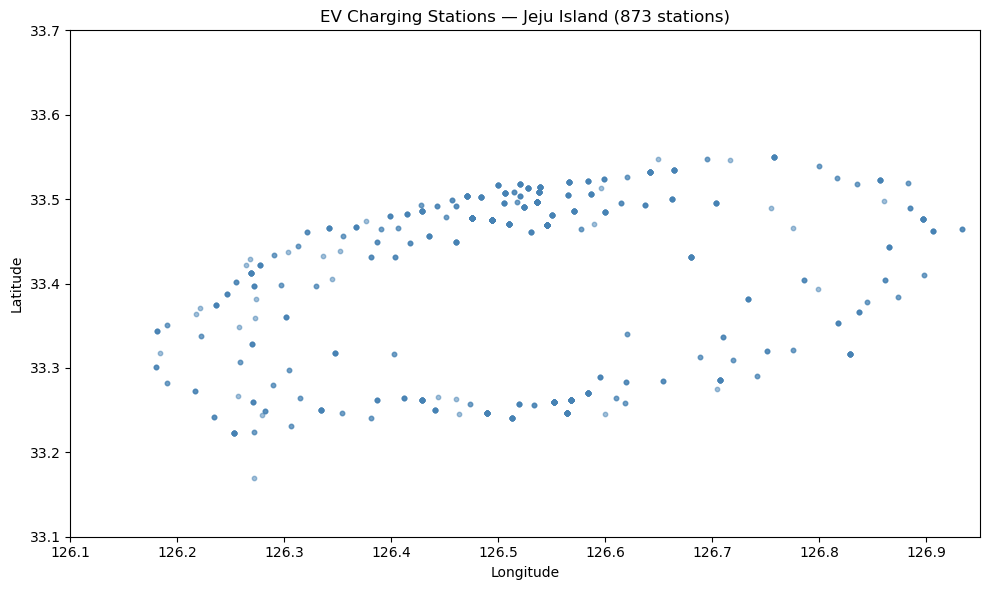

In [6]:
import matplotlib.pyplot as plt

coords = pd.read_csv(OUT_PATH).dropna(subset=['lat', 'lon'])

# Bounding box check
jeju_lat = (33.1, 33.7)
jeju_lon = (126.1, 126.95)

outside = coords[
    ~coords['lat'].between(*jeju_lat) |
    ~coords['lon'].between(*jeju_lon)
]
print(f'Stations outside Jeju bounding box: {len(outside)}')
if len(outside) > 0:
    print(outside[['customer_id', 'address', 'lat', 'lon', 'geocode_status']])

# Simple scatter plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(coords['lon'], coords['lat'], s=10, alpha=0.5, color='steelblue')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'EV Charging Stations — Jeju Island ({len(coords)} stations)')
ax.set_xlim(jeju_lon)
ax.set_ylim(jeju_lat)
plt.tight_layout()
plt.show()